In [3]:
from DataProcessing import Readout
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
from scipy.ndimage import gaussian_filter
rcParams['font.family'] = 'Times New Roman'
rcParams['mathtext.fontset'] = 'stix'
rcParams['axes.unicode_minus'] = False
rcParams.update({
	'font.size': 14,
	'axes.titlesize': 14,
	'axes.labelsize': 14,
	'xtick.labelsize': 14,
	'ytick.labelsize': 14,
	'legend.fontsize': 14,
	'figure.titlesize': 14,
	'legend.frameon': False,
})

In [5]:
root_dir = "Z:/migratedData/Rydberg_QIS/data"
_,_,atoms,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2026/04/19", plot_id=13)
atoms = atoms.T.astype(np.float64)
_,_,ref,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2026/04/19", plot_id=14)
ref = ref.T.astype(np.float64)
_,_,dark,notes = Readout.read_saved_csv_by_id(root_dir=root_dir, date="2026/04/19", plot_id=15)
dark = dark.T.astype(np.float64)

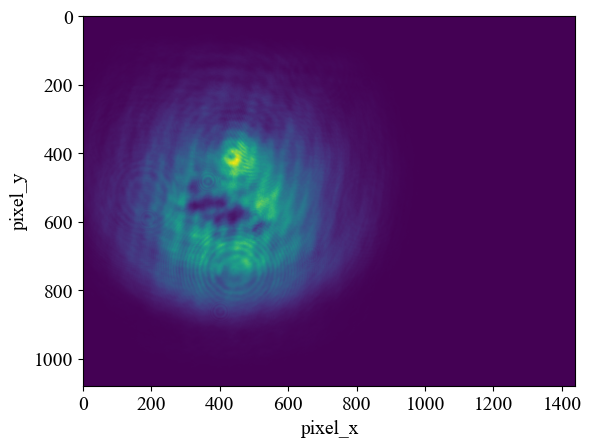

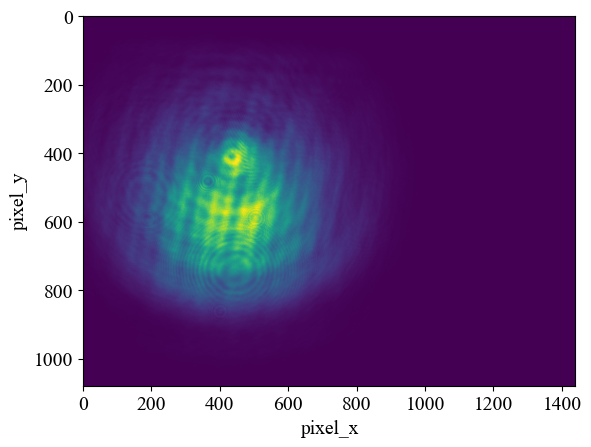

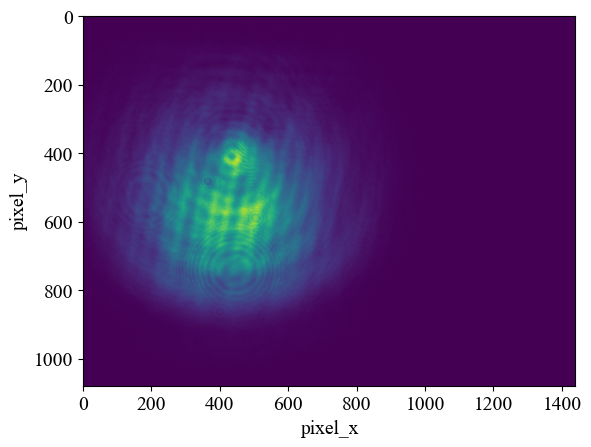

In [7]:
# plt.pcolormesh(x,y,z.T)
plt.imshow(atoms)
plt.xlabel(notes["xlabel"])
plt.ylabel(notes["ylabel"])
plt.show()
# cbar = plt.colorbar()
# cbar.set_label(notes["zlabel"])

plt.imshow(ref)
plt.xlabel(notes["xlabel"])
plt.ylabel(notes["ylabel"])
plt.show()

plt.imshow(dark)
plt.xlabel(notes["xlabel"])
plt.ylabel(notes["ylabel"])
plt.show()

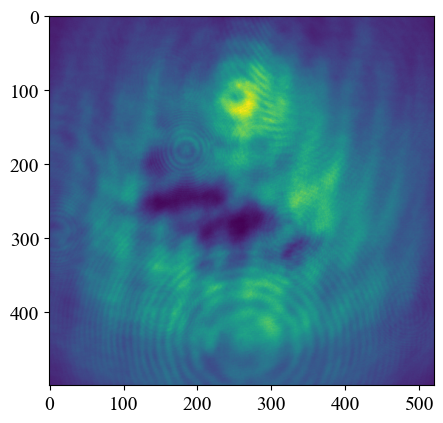

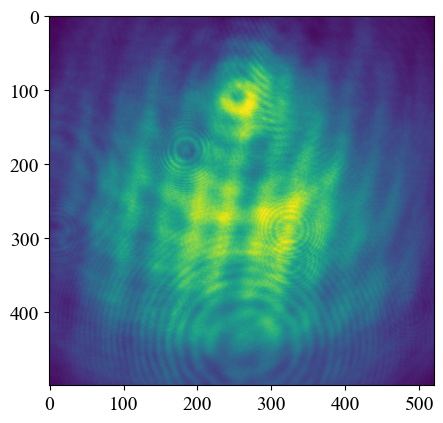

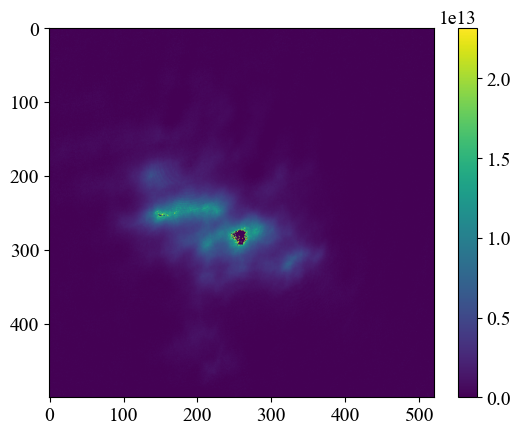

2063704.4620965382


In [23]:
# def ShadowImage(atoms, ref, dark, s = 0, sigma0 = 4.849e-13, pixel_size = 3.45e-06, mag_factor = 1.0):

s = 0.7
sigma0 = 4.849e-13
pixel_size = 3.45e-06
mag_factor = 1.0

A_pixel = (pixel_size/mag_factor)**2
a = atoms.astype(np.float64)[300:800,180:700]
d = dark.astype(np.float64)[300:800,180:700]
r = ref.astype(np.float64)[300:800,180:700]
up = a - d
plt.imshow(up)
plt.show()
down = r - d
plt.imshow(down)
plt.show()
epsilon = 1e-6
mask = (down<=0) | (up <=0)
up[mask] = epsilon
down[mask] = epsilon
ratio = up/down
# plt.imshow(ratio)
# plt.show()

od = -np.log(ratio)
od[od<0]=0
sigma = sigma0/(1 + s)

density = od/(sigma)
plt.imshow(density)
plt.colorbar()
plt.show()
total_num = np.sum(density * A_pixel)
print(total_num)

In [12]:
from scipy.ndimage import label

[[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]


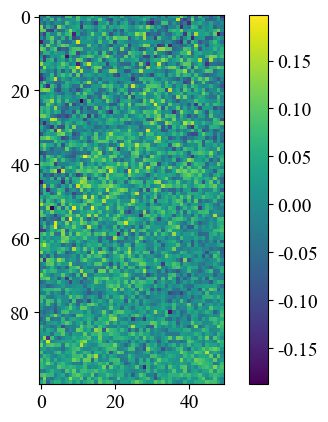

In [9]:
up = atoms-dark
# print(up)
down = ref - dark
epsilon = 1e-6
threshold_OD = 0.05

mask = (down<=0) | (up <=0)

up[mask] = epsilon
down[mask] =epsilon
# print(up)
ratio = up/down
print(ratio)

# print(ratio[:50,:50])

od = -np.log(ratio[300:400,150:200])

# od_mask = od > threshold_OD

# mot,label_num = label(od_mask)
# print(label_num)
# print(np.max(mot))

# sizes= []
# for i in range(1,label_num+1):
#     size = np.sum((mot == i))
    
#     sizes.append(size)

# largest_label = np.argmax(sizes) + 1


# mot_mask = ( mot == largest_label)
plt.imshow(od)
plt.colorbar()
plt.show()


# plt.imshow(mot_mask)
# plt.colorbar()
# plt.show()

In [5]:
od[od<0]=0

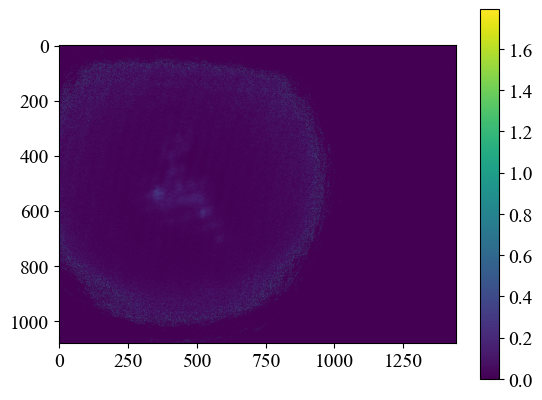

In [6]:
# mot_mask = ( mot== largest_label)
plt.imshow(od)
# plt.imshow(mot_mask)
# plt.figure(figsize=(32, 24))
plt.colorbar()
plt.show()

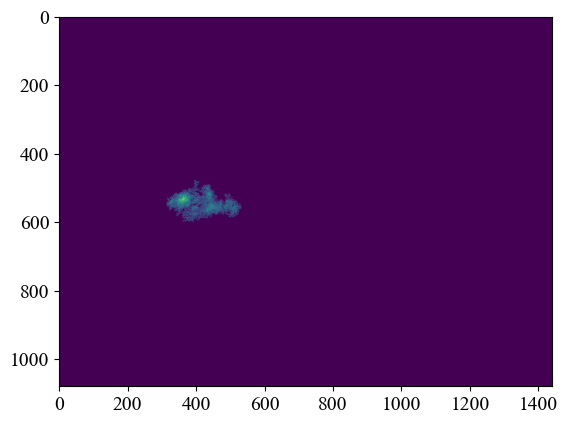

In [47]:


actual_MOT = od * mot_mask
plt.imshow(actual_MOT)
# plt.colorbar()
plt.show()

In [9]:
Isat = 31.3  # W/m^2


sigma0 = 4.849e-13  #m^2

pixel_size = 3.45e-06                   # camera pixel size [m]
mag_factor = 1.0                        # magnfication factor from 4f imaging system
A_pixel = (pixel_size/mag_factor)**2    # pixel area [m^2]



C:\Users\20629\AppData\Local\Temp\ipykernel_46664\4060100436.py:1: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(od[200:800,250:750])
C:\Users\20629\AppData\Local\Temp\ipykernel_46664\4060100436.py:1: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.imshow(od[200:800,250:750])


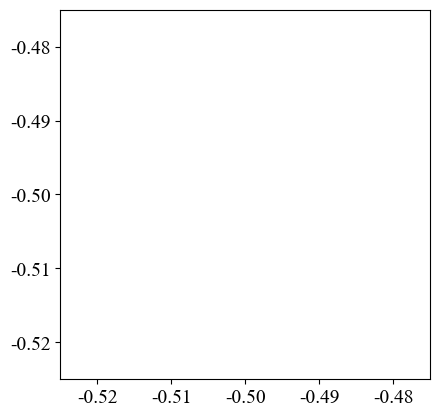

In [11]:
plt.imshow(od[200:800,250:750])

-7.688e+04


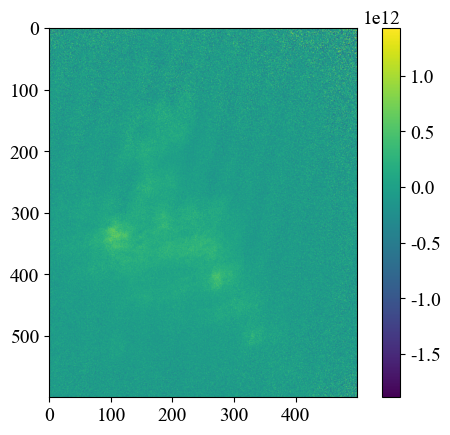

In [12]:
density = od[200:800,250:750]/(sigma0)
plt.imshow(density)
plt.colorbar()

total_num = np.sum(density * A_pixel)
print(f"{total_num:.3e}")

In [42]:
up.dtype

dtype('int64')

[[ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  1.]
 [ 0.  1.  0. ...  0.  1.  0.]
 ...
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0.  0.  0.]
 [ 0.  0.  0. ...  0. -1.  0.]]


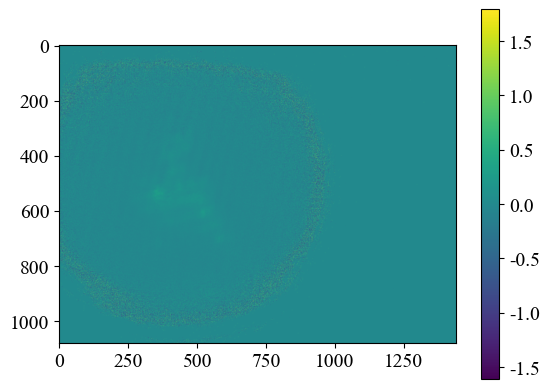

In [85]:
up = atoms-dark
print(up)
down = ref - dark
epsilon = 1e-6
threshold_OD = 0.05

mask = (down<=0) | (up <=0)

up[mask] = epsilon
down[mask] =epsilon
# print(up)
ratio = up/down

# print(ratio[:50,:50])

od = -np.log(ratio)

# od_mask = od > threshold_OD

# mot,label_num = label(od_mask)
# print(label_num)
# print(np.max(mot))

# sizes= []
# for i in range(1,label_num+1):
#     size = np.sum((mot == i))
    
#     sizes.append(size)

# largest_label = np.argmax(sizes) + 1


# mot_mask = ( mot == largest_label)
plt.imshow(od)
plt.colorbar()
plt.show()


# plt.imshow(mot_mask)
# plt.colorbar()
# plt.show()

In [104]:
def ShadowImage(atoms, ref, dark, Isat = 31.3, sigma0 = 4.849e-13, pixel_size = 3.45e-06, mag_factor = 1.0):
    A_pixel = (pixel_size/mag_factor)**2
    up = (atoms-dark).astype(np.float64)
    down = (ref - dark).astype(np.float64)
    epsilon = 1e-6
    mask = (down<=0) | (up <=0)
    up[mask] = epsilon
    down[mask] = epsilon

    ratio = up/down
    od = -np.log(ratio)
    od[od<0]=0
    density = od/(sigma0)
    plt.imshow(density)
    plt.colorbar()

    total_num = np.sum(density * A_pixel)
    
    return total_num

187230.69609359736


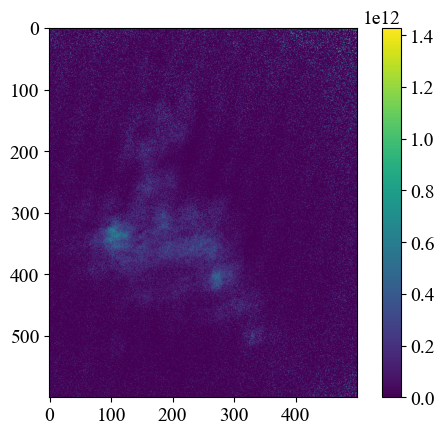

In [106]:
N = ShadowImage(atoms[200:800,250:750],ref[200:800,250:750],dark[200:800,250:750])
print(N)